In [1]:
import pandas as pd
import numpy as np
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, accuracy_score, f1_score, confusion_matrix, precision_score
# from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import joblib

In [2]:
url = "https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset?utm_source=chatgpt.com"

In [3]:
# od.download(url)

In [4]:
df = pd.read_csv("/home/rohan/PyCharmMiscProject/.venv/AIML/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

### Data Understanding And Cleaning

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.shape

(1470, 35)

In [56]:
df["WorkLifeBalance"].unique()

array([1, 3, 2, 4])

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## EmployeeCount, StandardHours, Over18 are Data Leakage Here

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df["EmployeeNumber"].is_unique
# Conculsion - Identifier is Unique

True

In [12]:
df.isnull().sum()
# There is no Null Values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [14]:
for i in df.columns:
    print("Unique Values ", i, "-", df[i].unique(), "\n\n")

Unique Values  Age - [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60] 


Unique Values  Attrition - ['Yes' 'No'] 


Unique Values  BusinessTravel - ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] 


Unique Values  DailyRate - [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 103

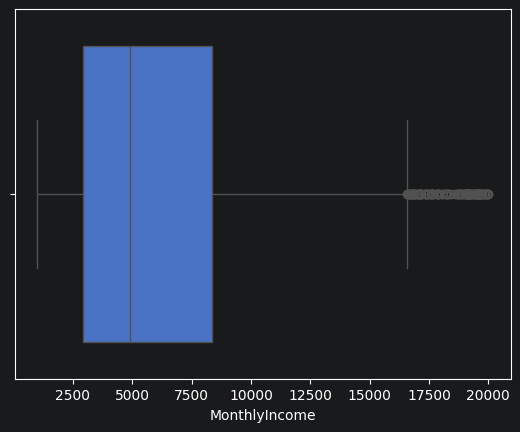

In [15]:
sns.boxplot(x = df["MonthlyIncome"])
plt.show()

# MonthlyIncome is Right Skewed

In [16]:
Q1 = df["MonthlyIncome"].quantile(0.25)
Q2 = df["MonthlyIncome"].median()
Q3 = df["MonthlyIncome"].quantile(0.75)
IQR = Q3 - Q1

In [17]:
print("Q1 : ", Q1)
print("Q2 : ", Q2)
print("Q3 : ", Q3)

Q1 :  2911.0
Q2 :  4919.0
Q3 :  8379.0


In [18]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [19]:
Outlier = df[(df["MonthlyIncome"] > upper) | (df["MonthlyIncome"] < lower)]

In [20]:
Outlier["MonthlyIncome"]

25      19094
29      18947
45      19545
62      18740
105     18844
        ...  
1374    17875
1377    19161
1401    19636
1437    19431
1443    18880
Name: MonthlyIncome, Length: 114, dtype: int64

In [21]:
Outlier.shape

(114, 35)

## From the Documentation or Dataset's Dictionary, the Education, Job satisfaction, JobLevel are Ordinal Encoded


In [22]:
obj = df.select_dtypes(object).columns

In [23]:
for i in obj:
    print(df[i].value_counts(), "\n\n")

Attrition
No     1233
Yes     237
Name: count, dtype: int64 


BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64 


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64 


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64 


Gender
Male      882
Female    588
Name: count, dtype: int64 


JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64 


MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64 


Over18
Y

In [24]:
# for i in obj:
#     sns.countplot(data = df, x = i)
#     plt.title(f"Employee {i} Distribution")
#     plt.xlabel(i)
#     plt.ylabel("Count")
#     plt.show()

### Feature Engineering

In [25]:
df.drop(columns = ["EmployeeCount", "Over18", "StandardHours"], axis = 1, inplace = True)

In [26]:
df.shape

(1470, 32)

In [27]:
print(obj)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [28]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [29]:
df.select_dtypes(object).columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [30]:
df.select_dtypes(int).columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [31]:
preprocessor = ColumnTransformer(transformers = [("Travel", OrdinalEncoder(categories=[['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]), ["BusinessTravel"]), ("Nominal", OneHotEncoder(handle_unknown="ignore", drop = "first"), ['Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime']), ("Scale", StandardScaler(), ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',  'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'])], remainder = "drop")

In [32]:
preprocessor

,transformers,"[('Travel', ...), ('Nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,"[['Non-Travel', 'Travel_Rarely', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [33]:
y = LabelEncoder().fit_transform(df["Attrition"])

In [34]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [35]:
X = df[['Age', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [37]:
df[df.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [38]:
para = {"model__n_estimators":[100, 150, 180, 200], "model__criterion": ["gini", "entropy"],
             "model__max_depth": [1, 2, 3],
             "model__min_samples_split": [1, 2, 3],
             "model__min_samples_leaf": [1, 2, 3]
        }

In [39]:
# pipe = Pipeline(steps = [("Preprocessor", preprocessor), ("model", RandomForestClassifier(n_estimators= 150,random_state=42, criterion = 'gini', max_depth = 3, min_samples_leaf = 1, min_samples_split = 3,
    # class_weight="balanced"))])


pipe = Pipeline(steps = [("Preprocessor", preprocessor), ("model", LogisticRegression(random_state = 42))])

In [40]:
# grid = GridSearchCV(estimator=pipe, param_grid = para, cv = 3, scoring = "recall", n_jobs = -1)
# grid.fit(X_train, y_train)
# print(grid.best_params_)
# print(grid.best_score_)
# best_model = grid.best_estimator_
#
# output = best_model.predict(X_test)
#
# print(classification_report(y_test, output))
# print(confusion_matrix(y_test, output))

In [41]:
pipe

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Travel', ...), ('Nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
pipe.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Travel', ...), ('Nominal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
pipe.predict_proba(X_test)[:10, 1]

array([0.15117035, 0.00859845, 0.21568442, 0.00632701, 0.19579549,
       0.39539044, 0.01735407, 0.01023585, 0.01064356, 0.06206842])

In [44]:
probability = pipe.predict_proba(X_test)[:, 1]
threshold = 0.1
output = (probability >= threshold).astype(int)

In [45]:
# probability = pipe.predict_proba(X_test)[:, 1]
# threshold = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
# # output = (probability >= threshold).astype(int)
# for i in threshold:
#     output = (probability >= i).astype(int)
#     print(f"Threshold {i}")
#     print(f"Confusion Matrix : {confusion_matrix(y_test, output)}")
#     print(f"F1 Score : {f1_score(y_test, output)}")
#     print(f"Recall : {recall_score(y_test, output)}")
#     print(classification_report(y_test, output))

In [46]:
print(classification_report(y_test, output))


              precision    recall  f1-score   support

           0       0.92      0.65      0.76       247
           1       0.28      0.70      0.40        47

    accuracy                           0.66       294
   macro avg       0.60      0.67      0.58       294
weighted avg       0.82      0.66      0.70       294



In [47]:
print(confusion_matrix(y_test, output))

[[160  87]
 [ 14  33]]


Model: Logistic Regression
Preprocessing: ColumnTransformer
Threshold: 0.1
Random State: 42

### Model: Logistic Regression
### Preprocessing: ColumnTransformer
### Threshold: 0.1
### Random State: 42

### Final Evaluation

In [48]:
print("Accuracy:", accuracy_score(y_test, output))
print("Precision:", precision_score(y_test, output))
print("Recall:", recall_score(y_test, output))
print("F1 Score:", f1_score(y_test, output))

print("\nClassification Report:")
print(classification_report(y_test, output))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, output))

Accuracy: 0.6564625850340136
Precision: 0.275
Recall: 0.7021276595744681
F1 Score: 0.39520958083832336

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76       247
           1       0.28      0.70      0.40        47

    accuracy                           0.66       294
   macro avg       0.60      0.67      0.58       294
weighted avg       0.82      0.66      0.70       294


Confusion Matrix:
[[160  87]
 [ 14  33]]


### Model Interpretation

## Saving The Model

In [49]:
joblib.dump(pipe, "../Employees_Attrition_Prediction.pkl")

['Employees_Attrition_Prediction.pkl']

In [50]:
def Result(inp):
    probability = pipe.predict_proba(inp)[:, 1]
    # threshold = 0.1
    output = (probability >= 0.1).astype(int)